In [3]:
from google.colab import files

uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [4]:
# Read CSV and Train/Test Split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df = pd.read_csv("titanic.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (889, 13)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  embark_town  alone  
0    man        True  Southampton  False  
1  woman       False    Cherbourg  False  
2  woman       False  Southampton   True  
3  woman       False  Southampton  False  
4    man        True  Southampton   True  


In [5]:
# Class Balance
class_balance = df["survived"].value_counts()

class_percentage = (
    df["survived"]
    .value_counts(normalize=True)
    .mul(100)
)

balance_table = pd.DataFrame({
    "Count": class_balance,
    "Percentage": class_percentage
})

print("Survival Class Balance:")
print(balance_table)

Survival Class Balance:
          Count  Percentage
survived                   
0           549   61.754781
1           340   38.245219


In [6]:
# Select Features and Target
X = df[
    [
        "pclass",
        "age",
        "sibsp",
        "parch",
        "fare",
        "sex",
        "embarked"
    ]
]

y = df["survived"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex', 'embarked']

Target:
survived


In [7]:
# Stratified Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Distribution:")
print(y_test.value_counts(normalize=True))

Training Shape: (711, 7)
Testing Shape: (178, 7)

Training Class Distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing Class Distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


**Stratification** keeps approximately the same proportion of survived and not-survived passengers in both training and testing datasets.

In [8]:
# Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

# Numeric preprocessing
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Complete preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [9]:
# Train Three Classifiers

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Decision Tree
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

# Random Forest
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

for name, model in models.items():

    model.fit(X_train, y_train)

    print(name, "trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


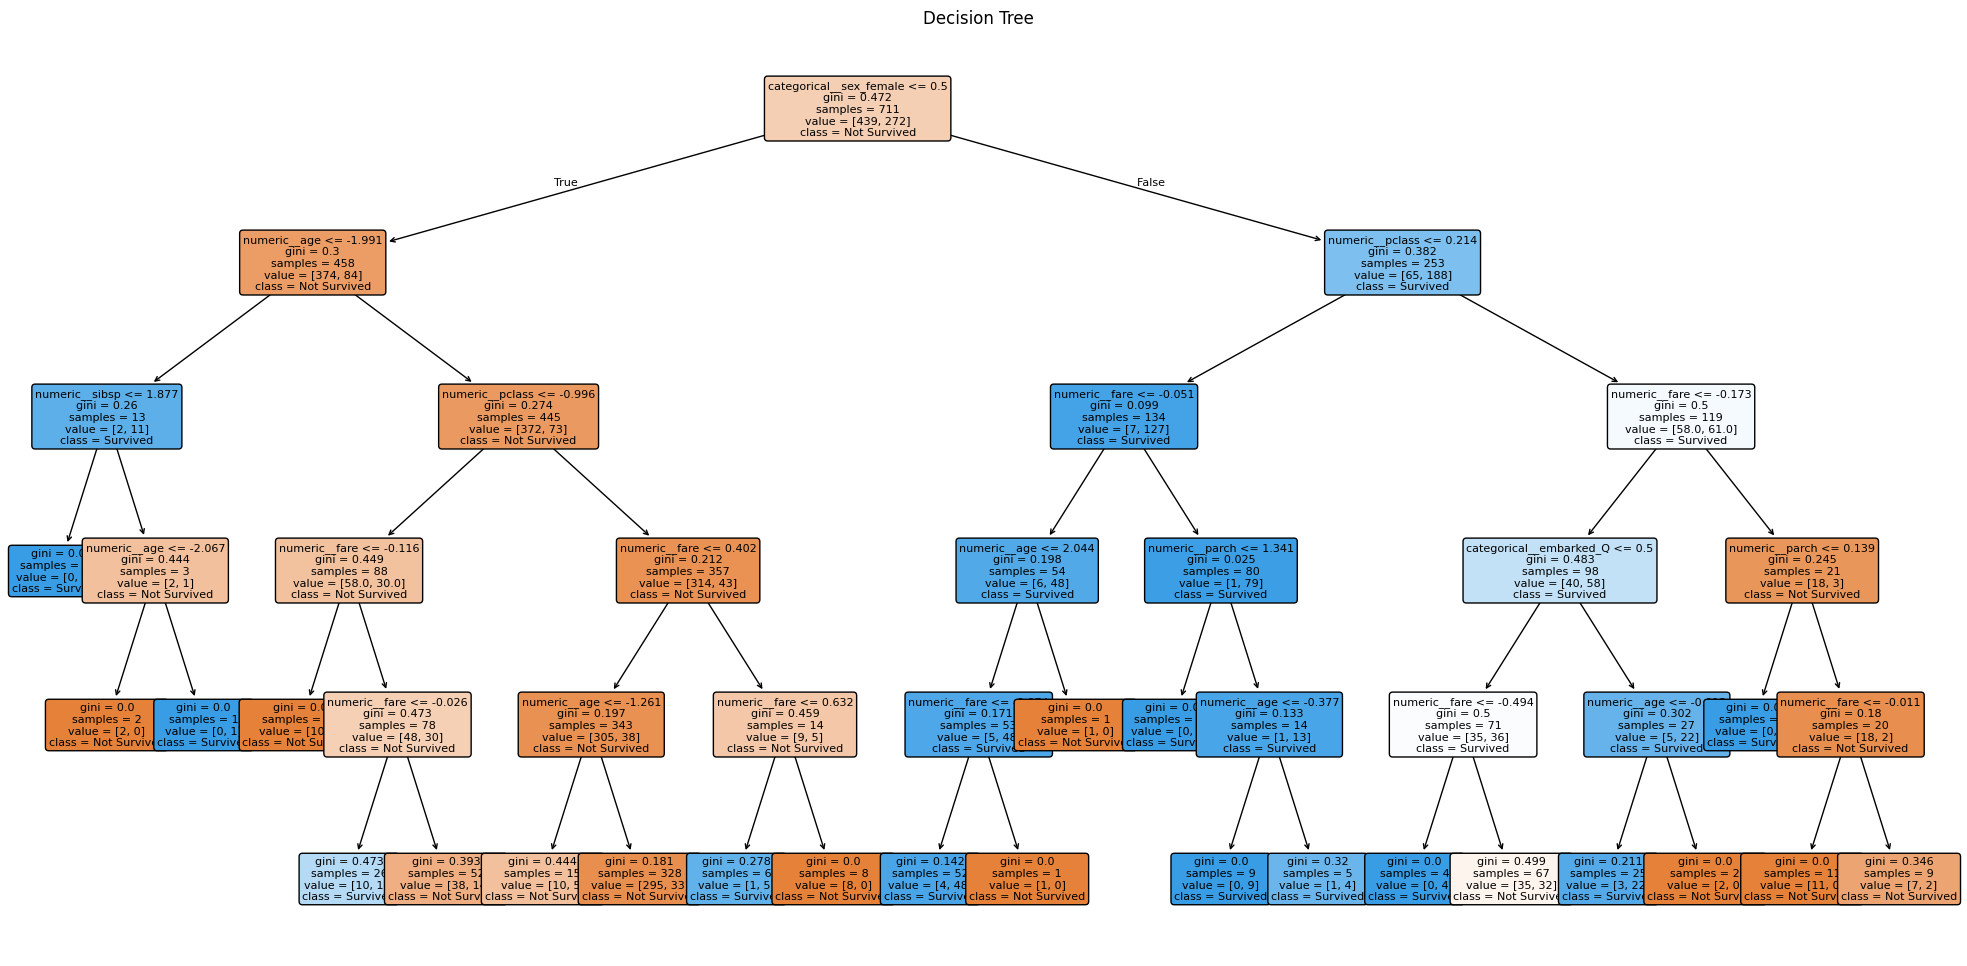

In [10]:
# Render Decision Tree
tree_preprocessor = (
    decision_tree_model
    .named_steps["preprocessor"]
)

tree_classifier = (
    decision_tree_model
    .named_steps["classifier"]
)

feature_names = (
    tree_preprocessor
    .get_feature_names_out()
)

plt.figure(figsize=(25, 12))

plot_tree(
    tree_classifier,
    feature_names=feature_names,
    class_names=[
        "Not Survived",
        "Survived"
    ],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree")
plt.show()

In [11]:
# Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "Confusion Matrix": cm,
        "Probabilities": y_prob,
        "Predictions": y_pred
    }

In [12]:
# Evaluate all models
results = {}

for name, model in models.items():

    results[name] = evaluate_model(
        model,
        X_test,
        y_test
    )

comparison_table = pd.DataFrame({
    name: {
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1": result["F1"],
        "AUC": result["AUC"]
    }
    for name, result in results.items()
}).T

print("========== MODEL COMPARISON ==========")

display(
    comparison_table.round(4)
)

========== MODEL COMPARISON ==========


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.809,0.7833,0.6912,0.7344,0.8610
Decision Tree,0.764,0.7600,0.5588,0.6441,0.8374
Random Forest,0.809,0.7656,0.7206,0.7424,0.8196


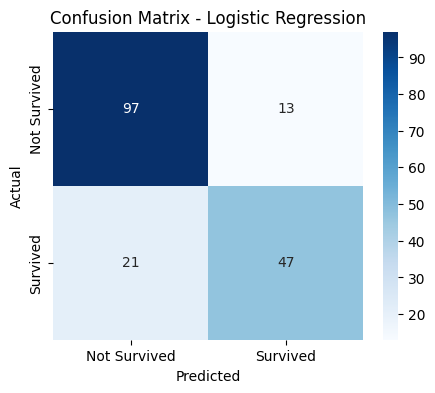

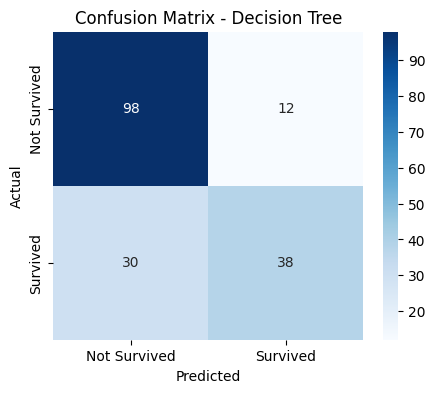

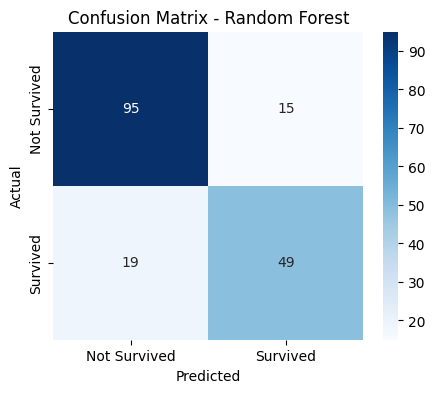

In [13]:
# Confusion Matrices
for name, result in results.items():

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        result["Confusion Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Not Survived",
            "Survived"
        ],
        yticklabels=[
            "Not Survived",
            "Survived"
        ]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

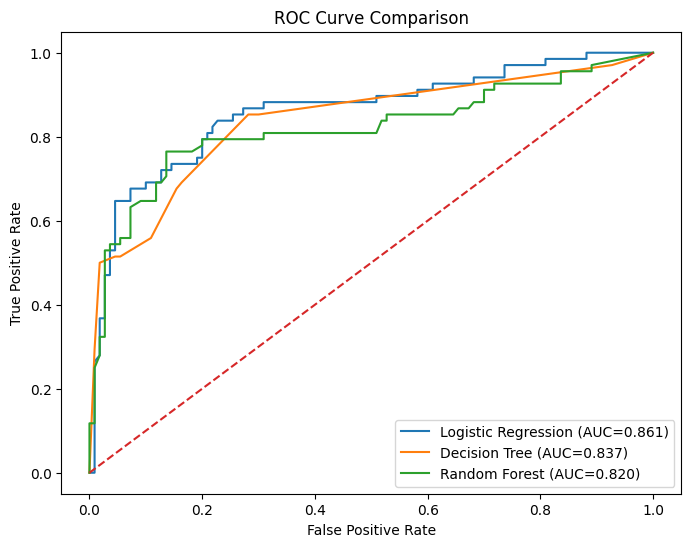

In [14]:
# ROC Curves
plt.figure(figsize=(8, 6))

for name, result in results.items():

    fpr, tpr, thresholds = roc_curve(
        y_test,
        result["Probabilities"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={result['AUC']:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [15]:
# Handle Class Imbalance
# Baseline
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

baseline_model.fit(
    X_train,
    y_train
)

baseline_result = evaluate_model(
    baseline_model,
    X_test,
    y_test
)

In [16]:
# Class Weight Balanced
balanced_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

balanced_model.fit(
    X_train,
    y_train
)

balanced_result = evaluate_model(
    balanced_model,
    X_test,
    y_test
)

In [17]:
# SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),

    ("smote", SMOTE(
        random_state=42
    )),

    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

smote_model.fit(
    X_train,
    y_train
)

smote_result = evaluate_model(
    smote_model,
    X_test,
    y_test
)

In [18]:
# Compare
imbalance_table = pd.DataFrame({
    "Baseline": {
        "Precision": baseline_result["Precision"],
        "Recall": baseline_result["Recall"],
        "F1": baseline_result["F1"]
    },

    "Class Weight Balanced": {
        "Precision": balanced_result["Precision"],
        "Recall": balanced_result["Recall"],
        "F1": balanced_result["F1"]
    },

    "SMOTE": {
        "Precision": smote_result["Precision"],
        "Recall": smote_result["Recall"],
        "F1": smote_result["F1"]
    }

}).T

print("========== IMBALANCE COMPARISON ==========")

display(
    imbalance_table.round(4)
)

best_imbalance = (
    imbalance_table["F1"]
    .idxmax()
)

print(
    "Best strategy based on F1:",
    best_imbalance
)

========== IMBALANCE COMPARISON ==========


,Precision,Recall,F1
Baseline,0.7833,0.6912,0.7344
Class Weight Balanced,0.7183,0.7500,0.7338
SMOTE,0.7353,0.7353,0.7353


Best strategy based on F1: SMOTE


In [19]:
# Random Forest GridSearchCV

# GRID SEARCH

from sklearn.model_selection import GridSearchCV

rf_grid_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("classifier", RandomForestClassifier(
        random_state=42,
        oob_score=True,
        bootstrap=True
    ))
])

param_grid = {

    "classifier__n_estimators": [
        100,
        200,
        300
    ],

    "classifier__max_depth": [
        None,
        5,
        10,
        15
    ],

    "classifier__max_features": [
        "sqrt",
        "log2"
    ]
}

grid_search = GridSearchCV(
    estimator=rf_grid_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("========== BEST PARAMETERS ==========")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

========== BEST PARAMETERS ==========
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 300}

Best CV Score:
0.81995469319413


In [20]:
# OOB Score
best_rf_pipeline = grid_search.best_estimator_

best_rf_classifier = (
    best_rf_pipeline
    .named_steps["classifier"]
)

print("OOB Score:")
print(best_rf_classifier.oob_score_)

OOB Score:
0.8213783403656821


In [21]:
# Fare Regression

regression_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "sex",
    "embarked"
]

X_reg = df[regression_features]

y_reg = df["fare"]

In [22]:
# Split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [23]:
# Regression preprocessing
reg_numeric_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            reg_numeric_pipeline,
            reg_numeric_features
        ),
        (
            "categorical",
            reg_categorical_pipeline,
            reg_categorical_features
        )
    ]
)

In [24]:
# Linear Regression
from sklearn.linear_model import LinearRegression

regression_model = Pipeline(steps=[

    ("preprocessor", reg_preprocessor),

    ("regressor", LinearRegression())
])

regression_model.fit(
    X_reg_train,
    y_reg_train
)

y_reg_pred = regression_model.predict(
    X_reg_test
)

In [25]:
# Regression Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

MAE = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

RMSE = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

R2 = r2_score(
    y_reg_test,
    y_reg_pred
)

n = len(y_reg_test)

X_reg_transformed = (
    regression_model
    .named_steps["preprocessor"]
    .transform(X_reg_test)
)

p = X_reg_transformed.shape[1]

Adjusted_R2 = (
    1 -
    ((1 - R2) * (n - 1))
    /
    (n - p - 1)
)

print("========== REGRESSION METRICS ==========")

print("MAE:", MAE)
print("RMSE:", RMSE)
print("R²:", R2)
print("Adjusted R²:", Adjusted_R2)

========== REGRESSION METRICS ==========
MAE: 21.098604259640428
RMSE: 41.70210467903215
R²: 0.348162572160543
Adjusted R²: 0.30913039085279115


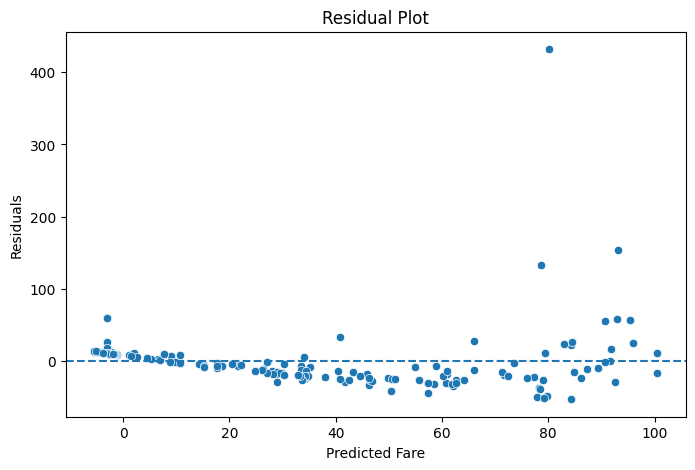

In [26]:
# Residual Plot
residuals = (
    y_reg_test -
    y_reg_pred
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [27]:
# Final Model Comparison

# First evaluate the tuned Random Forest.
tuned_rf_result = evaluate_model(
    best_rf_pipeline,
    X_test,
    y_test
)

In [37]:

# CLASSIFICATION TABLE

classification_table = pd.DataFrame({
    "Logistic Regression": {
        "Accuracy": results["Logistic Regression"]["Accuracy"],
        "Precision": results["Logistic Regression"]["Precision"],
        "Recall": results["Logistic Regression"]["Recall"],
        "F1": results["Logistic Regression"]["F1"],
        "AUC": results["Logistic Regression"]["AUC"]
    },

    "Decision Tree": {
        "Accuracy": results["Decision Tree"]["Accuracy"],
        "Precision": results["Decision Tree"]["Precision"],
        "Recall": results["Decision Tree"]["Recall"],
        "F1": results["Decision Tree"]["F1"],
        "AUC": results["Decision Tree"]["AUC"]
    },

    "Random Forest": {
        "Accuracy": results["Random Forest"]["Accuracy"],
        "Precision": results["Random Forest"]["Precision"],
        "Recall": results["Random Forest"]["Recall"],
        "F1": results["Random Forest"]["F1"],
        "AUC": results["Random Forest"]["AUC"]
    },

    "Tuned Random Forest": {
        "Accuracy": tuned_rf_result["Accuracy"],
        "Precision": tuned_rf_result["Precision"],
        "Recall": tuned_rf_result["Recall"],
        "F1": tuned_rf_result["F1"],
        "AUC": tuned_rf_result["AUC"]
    }
}).T

print("Classification Model Comparison:")
display(classification_table.round(4))

Classification Model Comparison:


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374
Random Forest,0.8090,0.7656,0.7206,0.7424,0.8196
Tuned Random Forest,0.8371,0.8824,0.6618,0.7563,0.8389


In [38]:
# Final combined table

classification_final = classification_table.reset_index()

classification_final = classification_final.rename(
    columns={"index": "Model"}
)

classification_final.insert(
    0,
    "Model Type",
    "Classification"
)

# Add regression-only columns
classification_final["MAE"] = np.nan
classification_final["RMSE"] = np.nan
classification_final["R²"] = np.nan
classification_final["Adjusted R²"] = np.nan


# Regression row
regression_final = pd.DataFrame({
    "Model Type": ["Regression"],
    "Model": ["Linear Regression"],

    "Accuracy": [np.nan],
    "Precision": [np.nan],
    "Recall": [np.nan],
    "F1": [np.nan],
    "AUC": [np.nan],

    "MAE": [MAE],
    "RMSE": [RMSE],
    "R²": [R2],
    "Adjusted R²": [Adjusted_R2]
})


# Make sure both tables have same column order
columns = [
    "Model Type",
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC",
    "MAE",
    "RMSE",
    "R²",
    "Adjusted R²"
]

classification_final = classification_final[columns]
regression_final = regression_final[columns]


# Combine
final_table = pd.concat(
    [classification_final, regression_final],
    ignore_index=True
)

print("========== FINAL MODEL COMPARISON ==========")

display(
    final_table.round(4)
)

========== FINAL MODEL COMPARISON ==========


,Model Type,Model,Accuracy,Precision,Recall,F1,AUC,MAE,RMSE,R²,Adjusted R²
0,Classification,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610,NaN,NaN,NaN,NaN
1,Classification,Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374,NaN,NaN,NaN,NaN
2,Classification,Random Forest,0.8090,0.7656,0.7206,0.7424,0.8196,NaN,NaN,NaN,NaN
3,Classification,Tuned Random Forest,0.8371,0.8824,0.6618,0.7563,0.8389,NaN,NaN,NaN,NaN
4,Regression,Linear Regression,NaN,NaN,NaN,NaN,NaN,21.0986,41.7021,0.3482,0.3091


In [40]:
# Save Complete Pipeline
full_pipeline = best_rf_pipeline

joblib.dump(
    full_pipeline,
    "best_titanic_pipeline.joblib"
)

print(
    "Complete pipeline saved successfully!"
)

Complete pipeline saved successfully!


In [41]:
# Reload Pipeline
loaded_pipeline = joblib.load(
    "best_titanic_pipeline.joblib"
)

print(
    "Pipeline loaded successfully!"
)

Pipeline loaded successfully!


In [42]:
# Test with Raw New Passenger Data
raw_passenger = pd.DataFrame({

    "pclass": [3],

    "sex": ["male"],

    "age": [25],

    "sibsp": [0],

    "parch": [0],

    "fare": [7.25],

    "embarked": ["S"]
})

prediction = loaded_pipeline.predict(
    raw_passenger
)

probability = loaded_pipeline.predict_proba(
    raw_passenger
)

print("========== RAW PASSENGER ==========")

display(raw_passenger)

print(
    "Prediction:",
    prediction[0]
)

print(
    "Prediction Label:",
    "Survived"
    if prediction[0] == 1
    else "Not Survived"
)

print(
    "Probability:",
    probability[0]
)

========== RAW PASSENGER ==========


,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,25,0,0,7.25,S


Prediction: 0
Prediction Label: Not Survived
Probability: [0.90675052 0.09324948]
